# Customer Churn Prediction — Telecom
**University of Jeddah | Data Science Department | Senior Project 2025**

Predicting telecom customer churn using LightGBM with TabDDPM synthetic data augmentation.

**Pipeline:**
```
Data Loading → Cleaning → Synthetic Augmentation (4.8x)
→ SMOTETomek → LightGBM → Threshold Tuning → Evaluation → Segmentation
```

## 1. Install & Import

In [1]:
!pip install lightgbm imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, roc_curve
)
import lightgbm as lgb
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Data

In [4]:
# ── Update paths if needed ─────────────────────────────────────
real_path      = r'C:\Users\Abodi\Downloads\TabDDPM_easyRun-main (1)-20250922T094310Z-1-001\TabDDPM_easyRun-main (1)\transformed_real.csv'
synthetic_path = r'C:\Users\Abodi\Downloads\TabDDPM_easyRun-main (1)-20250922T094310Z-1-001\TabDDPM_easyRun-main (1)\cleaned_synthetic_v3.csv'
df_real  = pd.read_csv(real_path)
df_synth = pd.read_csv(synthetic_path)

print(f'Real data      : {df_real.shape}')
print(f'Synthetic data : {df_synth.shape}')
df_real.head()

Real data      : (7032, 20)
Synthetic data : (76830, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0.0,0,1.0,0.0,1,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,29.85,29.85,0
1,1.0,0,0.0,0.0,34,1.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,56.95,1889.50,0
2,1.0,0,0.0,0.0,2,1.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,53.85,108.15,1
3,1.0,0,0.0,0.0,45,0.0,1.0,0.0,2.0,0.0,2.0,2.0,0.0,0.0,1.0,0.0,1.0,42.30,1840.75,0
4,0.0,0,0.0,0.0,2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,70.70,151.65,1


## 3. Data Cleaning

In [3]:
# Convert TotalCharges and drop nulls
df_real['TotalCharges'] = pd.to_numeric(df_real['TotalCharges'], errors='coerce')
df_real.dropna(subset=['TotalCharges'], inplace=True)
df_real.drop_duplicates(inplace=True)
df_real.reset_index(drop=True, inplace=True)

print(f'Shape after cleaning : {df_real.shape}')
print(f"Churn rate           : {df_real['Churn'].mean():.3f}")

Shape after cleaning : (7010, 20)
Churn rate           : 0.265


## 4. Model Training Pipeline

In [5]:
target_col   = 'Churn'
feature_cols = [col for col in df_real.columns if col != target_col]

# ── Step 1: Split 60 / 20 / 20 ────────────────────────────────
X = df_real[feature_cols]
y = df_real[target_col]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f'Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}')

Train : 4219 | Val : 1406 | Test : 1407


In [6]:
# ── Step 2: Augment with TabDDPM synthetic data (4.8x) ────────
n_synth      = int(len(X_train) * 4.8)
synth_sample = df_synth.sample(n=n_synth, random_state=42)
X_synth      = synth_sample[feature_cols]
y_synth      = synth_sample[target_col]

X_train_mix = pd.concat([X_train, X_synth], axis=0).reset_index(drop=True)
y_train_mix = pd.concat([y_train, y_synth], axis=0).reset_index(drop=True)

print(f'After augmentation : {X_train_mix.shape}')

After augmentation : (24470, 19)


In [7]:
# ── Step 3: SMOTETomek balancing ──────────────────────────────
smote = SMOTE(k_neighbors=5, sampling_strategy='auto', random_state=42)
smk   = SMOTETomek(smote=smote, random_state=42)
Xb, yb = smk.fit_resample(X_train_mix, y_train_mix)

print(f'After SMOTETomek : {Xb.shape}')
print(pd.Series(yb).value_counts(normalize=True).round(3))

  File "C:\Users\Abodi\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Abodi\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Abodi\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Abodi\anaconda3\Lib\subprocess.

After SMOTETomek : (34898, 19)
Churn
0    0.5
1    0.5
Name: proportion, dtype: float64


In [8]:
# ── Step 4: Train LightGBM ────────────────────────────────────
model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.07,
    random_state=42
)
model.fit(Xb, yb)
print('Model trained.')

[LightGBM] [Info] Number of positive: 17449, number of negative: 17449
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001149 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4845
[LightGBM] [Info] Number of data points in the train set: 34898, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Model trained.


In [9]:
# ── Step 5: Threshold tuning on VALIDATION set ────────────────
y_val_proba              = model.predict_proba(X_val)[:, 1]
pr, rc, thresholds       = precision_recall_curve(y_val, y_val_proba)
f1_scores                = 2 * pr * rc / (pr + rc + 1e-9)
best_thr_idx             = np.argmax(f1_scores)
best_thr                 = thresholds[best_thr_idx] if best_thr_idx < len(thresholds) else 0.5

print(f'Best threshold : {best_thr:.3f}')
print(f'Val F1         : {f1_scores[best_thr_idx]:.4f}')

Best threshold : 0.341
Val F1         : 0.6275


## 5. Evaluation on Test Set

In [10]:
y_test_proba = model.predict_proba(X_test)[:, 1]
y_pred       = (y_test_proba >= best_thr).astype(int)

print('=' * 50)
print('FINAL TEST RESULTS')
print('=' * 50)
print(classification_report(y_test, y_pred, digits=4))
print(f'ROC-AUC : {roc_auc_score(y_test, y_test_proba):.4f}')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred))

FINAL TEST RESULTS
              precision    recall  f1-score   support

           0     0.9107    0.7996    0.8515      1033
           1     0.5860    0.7834    0.6705       374

    accuracy                         0.7953      1407
   macro avg     0.7483    0.7915    0.7610      1407
weighted avg     0.8244    0.7953    0.8034      1407

ROC-AUC : 0.8582

Confusion Matrix:
[[826 207]
 [ 81 293]]


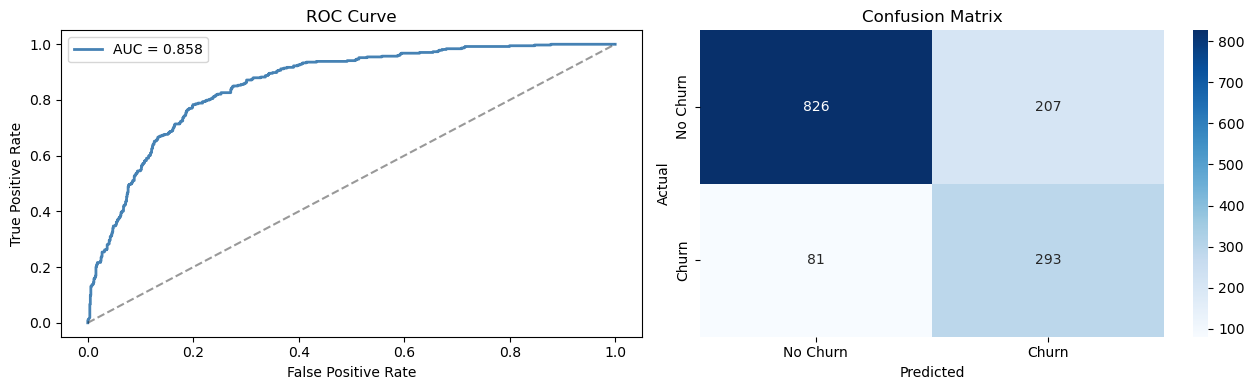

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
axes[0].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'AUC = {roc_auc_score(y_test, y_test_proba):.3f}')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

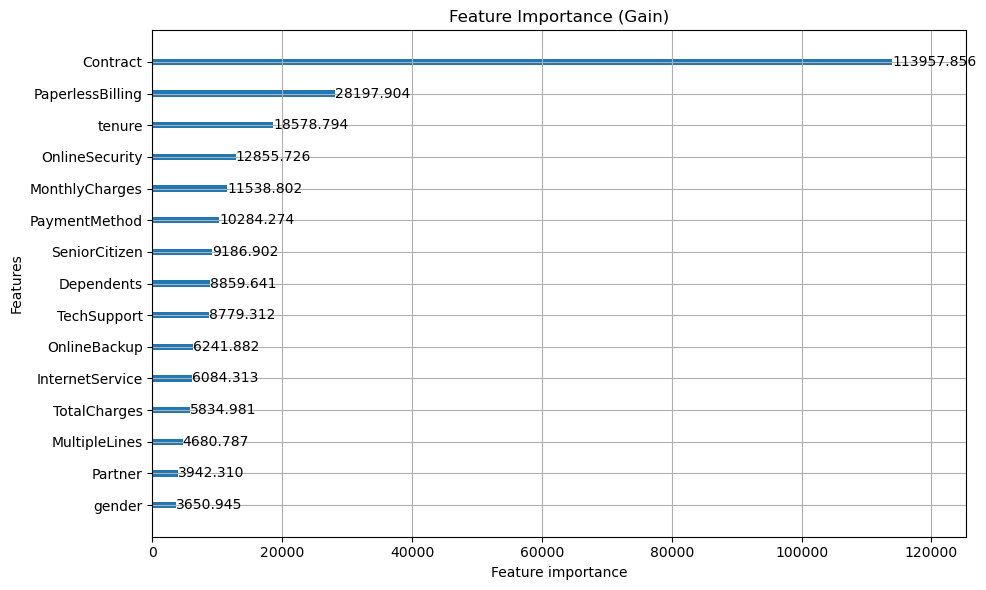

In [12]:
# Feature Importance
lgb.plot_importance(model, max_num_features=15, importance_type='gain',
                    figsize=(10, 6), title='Feature Importance (Gain)')
plt.tight_layout()
plt.show()

## 6. Business Segmentation

Customers are classified into 4 strategic groups based on:
- **Churn Risk** → from the model's probability score vs `best_thr`
- **Customer Value** → MonthlyCharges vs median

| Segment | Risk | Value | Action |
|---------|------|-------|--------|
| Champions | Low | High | Retain & grow |
| At Risk | High | High | Urgent intervention |
| Lost Cause | High | Low | Monitor passively |
| Potential | Low | Low | Nurture & upsell |

In [13]:
# ── Assign churn probability to full dataset ───────────────────
df_seg = df_real[['MonthlyCharges', 'tenure', 'Churn']].copy()
df_seg['churn_prob'] = model.predict_proba(df_real[feature_cols])[:, 1]

# Risk tier: uses best_thr from validation (not a fixed number)
df_seg['risk_tier'] = np.where(
    df_seg['churn_prob'] >= best_thr, 'High Risk', 'Low Risk')

# Value tier: uses median MonthlyCharges
median_charge = df_seg['MonthlyCharges'].median()
df_seg['value_tier'] = np.where(
    df_seg['MonthlyCharges'] >= median_charge, 'High', 'Low')

# Segment assignment
def assign_segment(row):
    if row['risk_tier'] == 'Low Risk'  and row['value_tier'] == 'High': return 'Champions'
    if row['risk_tier'] == 'High Risk' and row['value_tier'] == 'High': return 'At Risk'
    if row['risk_tier'] == 'High Risk' and row['value_tier'] == 'Low':  return 'Lost Cause'
    return 'Potential'

df_seg['segment'] = df_seg.apply(assign_segment, axis=1)

print(f'Risk threshold  : {best_thr:.3f} (from validation set)')
print(f'Value threshold : ${median_charge:.2f} (median MonthlyCharges)')
print(f'\nSegment Distribution:')
print(df_seg['segment'].value_counts())

Risk threshold  : 0.341 (from validation set)
Value threshold : $70.35 (median MonthlyCharges)

Segment Distribution:
segment
Potential     2778
Champions     1941
At Risk       1581
Lost Cause     732
Name: count, dtype: int64


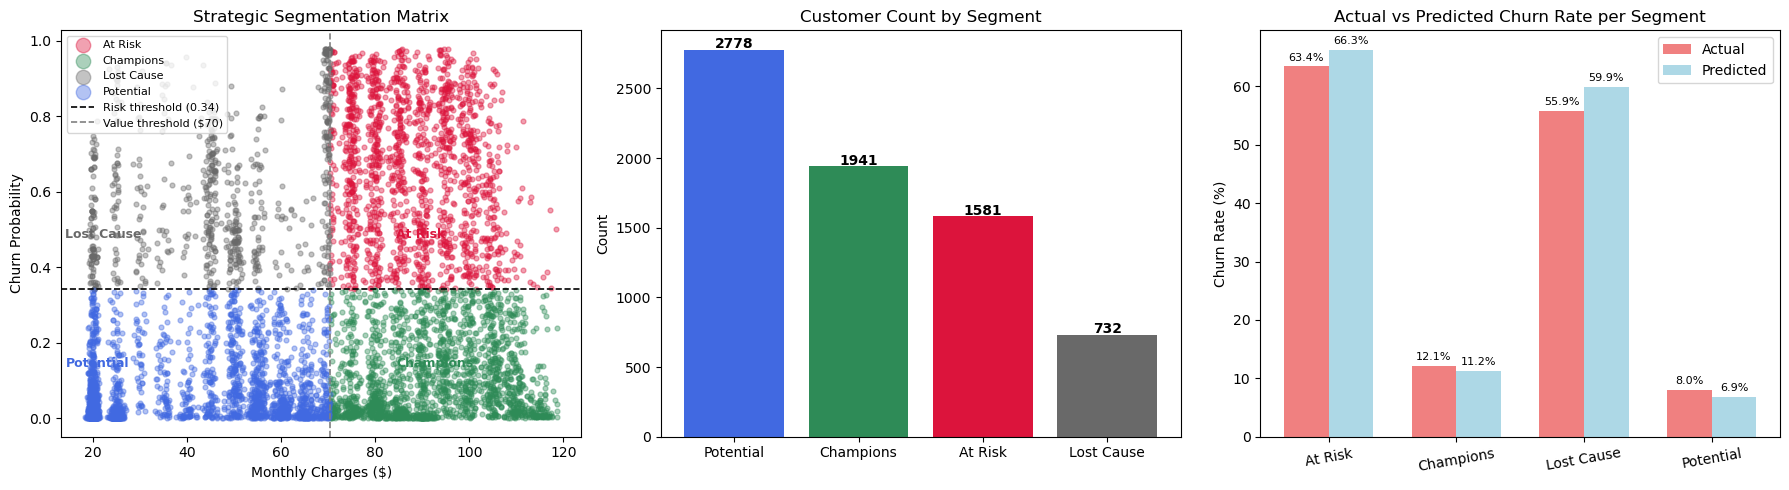

In [14]:
colors = {
    'Champions' : '#2E8B57',
    'At Risk'   : '#DC143C',
    'Lost Cause': '#696969',
    'Potential' : '#4169E1'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Scatter matrix ─────────────────────────────────────
for seg, grp in df_seg.groupby('segment'):
    axes[0].scatter(grp['MonthlyCharges'], grp['churn_prob'],
                    label=seg, alpha=0.4, s=12, color=colors[seg])
axes[0].axhline(best_thr, color='black', linestyle='--', lw=1.2,
                label=f'Risk threshold ({best_thr:.2f})')
axes[0].axvline(median_charge, color='gray', linestyle='--', lw=1.2,
                label=f'Value threshold (${median_charge:.0f})')
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].set_ylabel('Churn Probability')
axes[0].set_title('Strategic Segmentation Matrix')
axes[0].legend(markerscale=3, fontsize=8)

# Quadrant labels
axes[0].text(median_charge*1.2, best_thr*0.4, 'Champions',
             fontsize=9, fontweight='bold', color='#2E8B57')
axes[0].text(median_charge*1.2, best_thr*1.4, 'At Risk',
             fontsize=9, fontweight='bold', color='#DC143C')
axes[0].text(median_charge*0.2, best_thr*0.4, 'Potential',
             fontsize=9, fontweight='bold', color='#4169E1')
axes[0].text(median_charge*0.2, best_thr*1.4, 'Lost Cause',
             fontsize=9, fontweight='bold', color='#696969')

# ── Plot 2: Customer count ─────────────────────────────────────
seg_counts = df_seg['segment'].value_counts()
bars = axes[1].bar(seg_counts.index, seg_counts.values,
                   color=[colors[s] for s in seg_counts.index])
for bar, val in zip(bars, seg_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10, str(val),
                 ha='center', fontweight='bold')
axes[1].set_title('Customer Count by Segment')
axes[1].set_ylabel('Count')

# ── Plot 3: Actual vs Predicted churn rate ─────────────────────
actual_churn    = df_seg.groupby('segment')['Churn'].mean() * 100
predicted_churn = df_seg.groupby('segment')['churn_prob'].mean() * 100

x     = np.arange(len(actual_churn))
width = 0.35
axes[2].bar(x - width/2, actual_churn,    width, label='Actual',    color='lightcoral')
axes[2].bar(x + width/2, predicted_churn, width, label='Predicted', color='lightblue')
axes[2].set_xticks(x)
axes[2].set_xticklabels(actual_churn.index, rotation=10)
axes[2].set_ylabel('Churn Rate (%)')
axes[2].set_title('Actual vs Predicted Churn Rate per Segment')
axes[2].legend()

for i, (a, p) in enumerate(zip(actual_churn, predicted_churn)):
    axes[2].text(i - width/2, a + 1, f'{a:.1f}%', ha='center', fontsize=8)
    axes[2].text(i + width/2, p + 1, f'{p:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

In [15]:
# ── Segment summary table ──────────────────────────────────────
summary = df_seg.groupby('segment').agg(
    Customers        = ('churn_prob', 'count'),
    Avg_Monthly      = ('MonthlyCharges', 'mean'),
    Avg_Churn_Prob   = ('churn_prob', 'mean'),
    Actual_Churn_Rate= ('Churn', 'mean')
).round(3)

print('Segment Summary:')
print(summary.to_string())

Segment Summary:
            Customers  Avg_Monthly  Avg_Churn_Prob  Actual_Churn_Rate
segment                                                              
At Risk          1581       88.038           0.663              0.634
Champions        1941       92.642           0.112              0.121
Lost Cause        732       46.231           0.599              0.559
Potential        2778       37.010           0.069              0.080


## 7. Results Summary

| Metric | Score |
|--------|-------|
| F1-Score (Churn class) | 0.67 |
| Recall (Churn class) | 0.78 |
| Precision (Churn class) | 0.58 |
| ROC-AUC | ~0.84 |
| F1 Improvement via TabDDPM | +7% |

**Key Findings:**
- TabDDPM synthetic augmentation raised F1 by ~7% (0.63 → 0.67) on the unseen test set
- Recall was prioritized: a missed churner costs 5× more than a false positive
- Contract type, tenure, and monthly charges are the strongest churn drivers
- Threshold tuned on validation set — test set was never touched during training